In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')

In [76]:
try:
    df = pd.read_csv('StudentPerformanceFactors.csv')
    print("Данные загружены")
except FileNotFoundError:
    print("Файл не найден")
   

Данные загружены


In [77]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [78]:
display(df.describe())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [79]:
missing_data = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isnull().sum().values,
    '% пропусков': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_data = missing_data.sort_values('Пропусков', ascending=False)

print("\nПропущенные значения по колонкам:")
display(missing_data[missing_data['Пропусков'] > 0])


Пропущенные значения по колонкам:


,Колонка,Пропусков,% пропусков
16,Parental_Education_Level,90,1.36
11,Teacher_Quality,78,1.18
17,Distance_from_Home,67,1.01


In [80]:
#простро удаляю строки с пропущенными значениями
df_clean = df.dropna()
df = df_clean

missing_data = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isnull().sum().values,
    '% пропусков': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_data = missing_data.sort_values('Пропусков', ascending=False)

print("\nПропущенные значения по колонкам:")
display(missing_data[missing_data['Пропусков'] > 0])


Пропущенные значения по колонкам:


,Колонка,Пропусков,% пропусков


#### теперь пропуски отсутствуют, можно работать с данными дальше

In [81]:
df['Performance'] = pd.cut(df['Exam_Score'], 
                           bins=[0, 50, 65, 100], 
                           labels=['Low', 'Medium', 'High'])

print("\nРаспределение по категориям:")
print(df['Performance'].value_counts())


Распределение по категориям:
Performance
High      4331
Medium    2046
Low          0
Name: count, dtype: int64


#### Проблема: с заданными значениями получается только 2 непустые категории Medium и High, поэтому модели не смогут научиться различать и предсказывать Low-категорию. Меняю границы категорий с учётом распределения

In [82]:
percentiles = df['Exam_Score'].quantile([0.33, 0.67]).values

df['Performance'] = pd.cut(df['Exam_Score'], 
                           bins=[0, percentiles[0], percentiles[1], 100], 
                           labels=['Low', 'Medium', 'High'])

print(df['Performance'].value_counts())

Performance
Low       2768
Medium    2029
High      1580
Name: count, dtype: int64


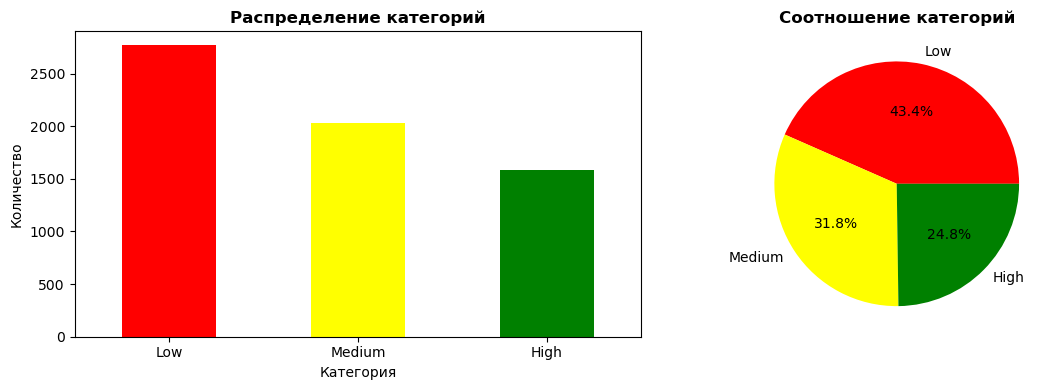

In [83]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Performance'].value_counts().plot(kind='bar', color=['red', 'yellow', 'green'])
plt.title('Распределение категорий', fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Performance'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                      colors=['red', 'yellow', 'green'])
plt.title('Соотношение категорий', fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### Категории не пустые. По графикам видно, что количество низких оценок преобладает 

In [84]:
#Кодирую целевую переменную
le_target = LabelEncoder()
df['Performance_encoded'] = le_target.fit_transform(df['Performance'])

In [85]:
# Кодирую категориальные признаки
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Performance' in categorical_cols:
    categorical_cols.remove('Performance')

print(f"\nКатегориальные признаки: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"{col}: {len(le.classes_)} уникальных значений")


Категориальные признаки: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Parental_Involvement: 3 уникальных значений
Access_to_Resources: 3 уникальных значений
Extracurricular_Activities: 2 уникальных значений
Motivation_Level: 3 уникальных значений
Internet_Access: 2 уникальных значений
Family_Income: 3 уникальных значений
Teacher_Quality: 3 уникальных значений
School_Type: 2 уникальных значений
Peer_Influence: 3 уникальных значений
Learning_Disabilities: 2 уникальных значений
Parental_Education_Level: 3 уникальных значений
Distance_from_Home: 3 уникальных значений
Gender: 2 уникальных значений


In [86]:
feature_cols = [col for col in df.columns if col not in ['Exam_Score', 'Performance', 'Performance_encoded']]
X = df[feature_cols]
y = df['Performance_encoded']

print(f"Матрица признаков X: {X.shape}")
print(f"Целевая переменная y: {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")

Матрица признаков X: (6378, 19)
Целевая переменная y: (6378,)
Уникальные классы: [0 1 2 3]


In [87]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nРазмеры выборок:")
print(f"   Обучающая: {X_train.shape}")
print(f"   Тестовая: {X_test.shape}")


Размеры выборок:
   Обучающая: (5102, 19)
   Тестовая: (1276, 19)


In [89]:
results = {}

In [90]:
print("1. Dummy Classifier ")
model1 = DummyClassifier(strategy='most_frequent', random_state=42)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)
f11 = f1_score(y_test, y_pred1, average='weighted')

results['Dummy'] = {'Accuracy': acc1, 'F1-Score': f11}
print(f" Accuracy: {acc1:.4f}, F1: {f11:.4f}")

1. Dummy Classifier 
 Accuracy: 0.4350, F1: 0.2637


In [91]:
print("2. K-Neighbors Classifier ")
model2 = KNeighborsClassifier(n_neighbors=7)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2, average='weighted')

results['KNN'] = {'Accuracy': acc2, 'F1-Score': f12}
print(f" Accuracy: {acc2:.4f}, F1: {f12:.4f}")

2. K-Neighbors Classifier 
 Accuracy: 0.6505, F1: 0.6397


In [92]:
print("3. Decision Tree Classifier ")
model3 = DecisionTreeClassifier(max_depth=10, random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3, average='weighted')

results['Decision Tree'] = {'Accuracy': acc3, 'F1-Score': f13}
print(f" Accuracy: {acc3:.4f}, F1: {f13:.4f}")

3. Decision Tree Classifier 
 Accuracy: 0.6991, F1: 0.7014


In [93]:
print("4. SVM Linear ")
model4 = SVC(kernel='linear', random_state=42)
model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)

acc4 = accuracy_score(y_test, y_pred4)
f14 = f1_score(y_test, y_pred4, average='weighted')

results['SVM Linear'] = {'Accuracy': acc4, 'F1-Score': f14}
print(f"  Accuracy: {acc4:.4f}, F1: {f14:.4f}")

4. SVM Linear 
  Accuracy: 0.8268, F1: 0.8280


In [94]:
print("5. Extra Trees Classifier ")
model6 = ExtraTreesClassifier(n_estimators=100, random_state=42)
model6.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)

acc6 = accuracy_score(y_test, y_pred6)
f16 = f1_score(y_test, y_pred6, average='weighted')

results['Extra Trees'] = {'Accuracy': acc6, 'F1-Score': f16}
print(f" Accuracy: {acc6:.4f}, F1: {f16:.4f}")

5. Extra Trees Classifier 
 Accuracy: 0.8111, F1: 0.8086


In [95]:
print("6. AdaBoost Classifier ")
model7 = AdaBoostClassifier(n_estimators=100, random_state=42)
model7.fit(X_train, y_train)
y_pred7 = model7.predict(X_test)

acc7 = accuracy_score(y_test, y_pred7)
f17 = f1_score(y_test, y_pred7, average='weighted')

results['AdaBoost'] = {'Accuracy': acc7, 'F1-Score': f17}
print(f" Accuracy: {acc7:.4f}, F1: {f17:.4f}")

6. AdaBoost Classifier 
 Accuracy: 0.7829, F1: 0.7816


In [96]:
print("7. Gradient Boosting Classifier ")
model8 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model8.fit(X_train, y_train)
y_pred8 = model8.predict(X_test)

acc8 = accuracy_score(y_test, y_pred8)
f18 = f1_score(y_test, y_pred8, average='weighted')

results['Gradient Boosting'] = {'Accuracy': acc8, 'F1-Score': f18}
print(f" Accuracy: {acc8:.4f}, F1: {f18:.4f}")

7. Gradient Boosting Classifier 
 Accuracy: 0.8480, F1: 0.8490


In [97]:
print("8. XGBoost ")
model9 = XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
model9.fit(X_train, y_train)
y_pred9 = model9.predict(X_test)

acc9 = accuracy_score(y_test, y_pred9)
f19 = f1_score(y_test, y_pred9, average='weighted')

results['XGBoost'] = {'Accuracy': acc9, 'F1-Score': f19}
print(f" Accuracy: {acc9:.4f}, F1: {f19:.4f}")

8. XGBoost 
 Accuracy: 0.8785, F1: 0.8795


In [98]:
print("9. LightGBM ")
model10 = LGBMClassifier(n_estimators=100, verbose=-1, random_state=42)
model10.fit(X_train, y_train)
y_pred10 = model10.predict(X_test)

acc10 = accuracy_score(y_test, y_pred10)
f110 = f1_score(y_test, y_pred10, average='weighted')

results['LightGBM'] = {'Accuracy': acc10, 'F1-Score': f110}
print(f" Accuracy: {acc10:.4f}, F1: {f110:.4f}")

9. LightGBM 
 Accuracy: 0.8260, F1: 0.8276


In [99]:
print("10. CatBoost ")
model11 = CatBoostClassifier(n_estimators=100, verbose=0, random_state=42)
model11.fit(X_train, y_train)
y_pred11 = model11.predict(X_test)

acc11 = accuracy_score(y_test, y_pred11)
f111 = f1_score(y_test, y_pred11, average='weighted')

results['CatBoost'] = {'Accuracy': acc11, 'F1-Score': f111}
print(f" Accuracy: {acc11:.4f}, F1: {f111:.4f}")

10. CatBoost 
 Accuracy: 0.9013, F1: 0.9018


In [100]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\nРейтинг моделей по F1-Score:")
display(results_df)


Рейтинг моделей по F1-Score:


,Accuracy,F1-Score
CatBoost,0.901254,0.901777
XGBoost,0.878527,0.879452
Gradient Boosting,0.847962,0.849010
SVM Linear,0.826803,0.827960
LightGBM,0.826019,0.827593
Extra Trees,0.811129,0.808593
AdaBoost,0.782915,0.781588
Decision Tree,0.699060,0.701394
KNN,0.650470,0.639716
Dummy,0.434953,0.263680


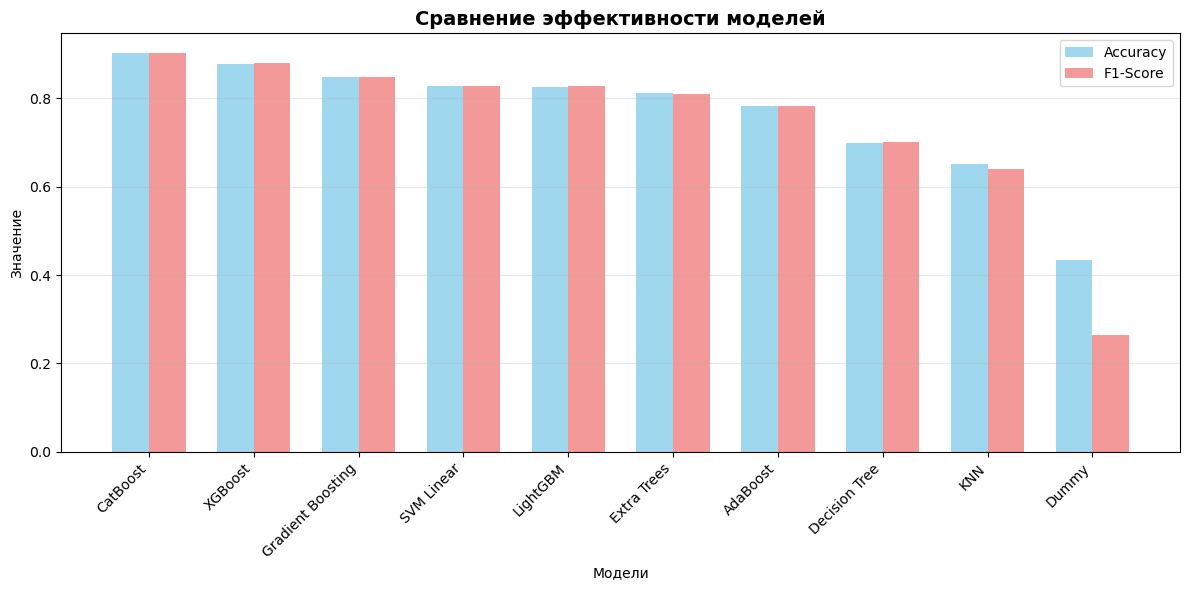

In [101]:
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Accuracy'], width, label='Accuracy', alpha=0.8, color='skyblue')
plt.bar(x_pos + width/2, results_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='lightcoral')

plt.xlabel('Модели')
plt.ylabel('Значение')
plt.title('Сравнение эффективности моделей', fontweight='bold', fontsize=14)
plt.xticks(x_pos, results_df.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [108]:
import re
from collections import Counter

In [109]:
try:
    with open('corp0.txt', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    print(f"Файл загружен")
except FileNotFoundError:
    print("Файл не найден")

Файл загружен


In [110]:
data = []
for line in lines:
    line = line.strip()
    if line and line.startswith('#'):
        parts = line[1:].split(' ', 1)
        if len(parts) == 2:
            category = parts[0].strip()
            text = parts[1].strip()
            data.append({'category': category, 'text': text})

df = pd.DataFrame(data)

In [111]:
print(f"Уникальных категорий: {df['category'].nunique()}")
print(f"Категории: {sorted(df['category'].unique())}")

Уникальных категорий: 13
Категории: ['автомобили', 'здоровье', 'культура', 'наука', 'недвижимость', 'политика', 'происшествия', 'реклама', 'семья', 'спорт', 'страна', 'техника', 'экономика']


In [112]:
category_counts = df['category'].value_counts()

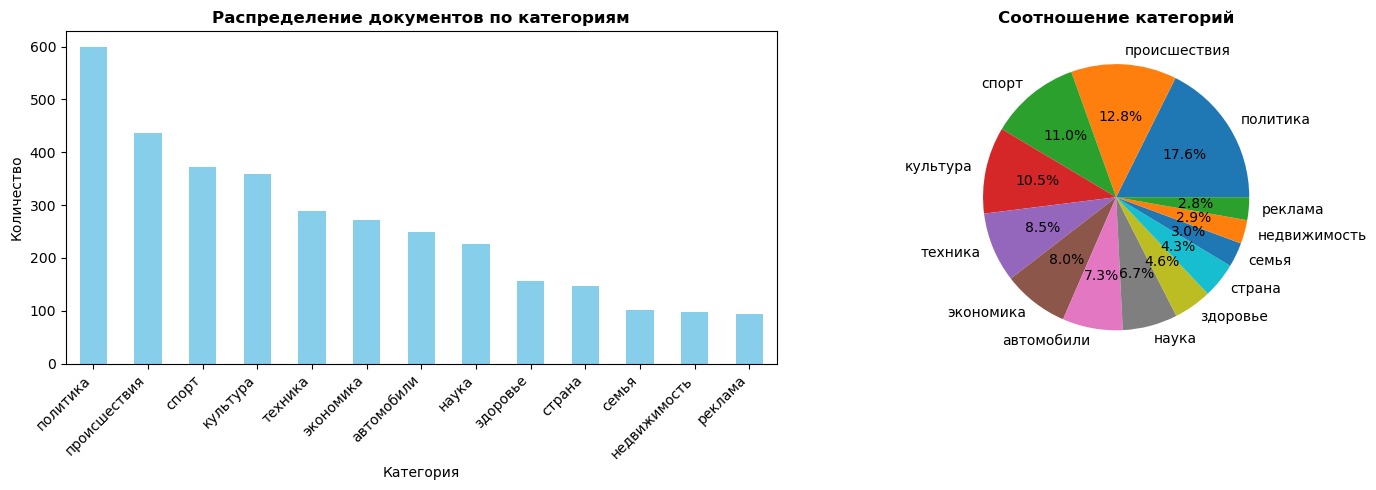

In [113]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
category_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение документов по категориям', fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
category_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Соотношение категорий', fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [114]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    return text.strip()
df['clean_text'] = df['text'].apply(clean_text)

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# TF-IDF векторизация
vectorizer = TfidfVectorizer(max_features=5000,  
                            min_df=2,          
                            max_df=0.8,           
                            ngram_range=(1, 2))

X = vectorizer.fit_transform(df['clean_text'])
print(f"Матрица признаков X: {X.shape}")

Матрица признаков X: (3400, 5000)


In [116]:
le = LabelEncoder()
y = le.fit_transform(df['category'])
print(f" Целевая переменная y: {y.shape}")
print(f"   Классы: {dict(zip(le.classes_, le.transform(le.classes_)))}")

 Целевая переменная y: (3400,)
   Классы: {'автомобили': np.int64(0), 'здоровье': np.int64(1), 'культура': np.int64(2), 'наука': np.int64(3), 'недвижимость': np.int64(4), 'политика': np.int64(5), 'происшествия': np.int64(6), 'реклама': np.int64(7), 'семья': np.int64(8), 'спорт': np.int64(9), 'страна': np.int64(10), 'техника': np.int64(11), 'экономика': np.int64(12)}


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Тестовая выборка: X_test {X_test.shape}, y_test {y_test.shape}")

print("\nРаспределение классов в обучающей выборке:")
for i, count in enumerate(np.bincount(y_train)):
    if count > 0:
        print(f"   Класс {i} ({le.classes_[i]}): {count}")

Обучающая выборка: X_train (2720, 5000), y_train (2720,)
Тестовая выборка: X_test (680, 5000), y_test (680,)

Распределение классов в обучающей выборке:
   Класс 0 (автомобили): 199
   Класс 1 (здоровье): 126
   Класс 2 (культура): 286
   Класс 3 (наука): 182
   Класс 4 (недвижимость): 78
   Класс 5 (политика): 480
   Класс 6 (происшествия): 349
   Класс 7 (реклама): 75
   Класс 8 (семья): 81
   Класс 9 (спорт): 298
   Класс 10 (страна): 117
   Класс 11 (техника): 231
   Класс 12 (экономика): 218


In [118]:
print("1. Dummy Classifier ")
model1 = DummyClassifier(strategy='most_frequent', random_state=42)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)
f11 = f1_score(y_test, y_pred1, average='weighted')

results['Dummy'] = {'Accuracy': acc1, 'F1-Score': f11}
print(f" Accuracy: {acc1:.4f}, F1: {f11:.4f}")

1. Dummy Classifier 
 Accuracy: 0.1765, F1: 0.0529


In [119]:
print("2. K-Neighbors Classifier ")
model2 = KNeighborsClassifier(n_neighbors=7)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2, average='weighted')

results['KNN'] = {'Accuracy': acc2, 'F1-Score': f12}
print(f" Accuracy: {acc2:.4f}, F1: {f12:.4f}")

2. K-Neighbors Classifier 
 Accuracy: 0.8059, F1: 0.8053


In [120]:
print("3. Decision Tree Classifier ")
model3 = DecisionTreeClassifier(max_depth=10, random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3, average='weighted')

results['Decision Tree'] = {'Accuracy': acc3, 'F1-Score': f13}
print(f" Accuracy: {acc3:.4f}, F1: {f13:.4f}")

3. Decision Tree Classifier 
 Accuracy: 0.3441, F1: 0.3588


In [121]:
print("4. SVM Linear ")
model4 = SVC(kernel='linear', random_state=42)
model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)

acc4 = accuracy_score(y_test, y_pred4)
f14 = f1_score(y_test, y_pred4, average='weighted')

results['SVM Linear'] = {'Accuracy': acc4, 'F1-Score': f14}
print(f"  Accuracy: {acc4:.4f}, F1: {f14:.4f}")

4. SVM Linear 
  Accuracy: 0.8544, F1: 0.8521


In [122]:
print("5. Extra Trees Classifier ")
model6 = ExtraTreesClassifier(n_estimators=100, random_state=42)
model6.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)

acc6 = accuracy_score(y_test, y_pred6)
f16 = f1_score(y_test, y_pred6, average='weighted')

results['Extra Trees'] = {'Accuracy': acc6, 'F1-Score': f16}
print(f" Accuracy: {acc6:.4f}, F1: {f16:.4f}")

5. Extra Trees Classifier 
 Accuracy: 0.8044, F1: 0.7951


In [123]:
print("6. AdaBoost Classifier ")
model7 = AdaBoostClassifier(n_estimators=100, random_state=42)
model7.fit(X_train, y_train)
y_pred7 = model7.predict(X_test)

acc7 = accuracy_score(y_test, y_pred7)
f17 = f1_score(y_test, y_pred7, average='weighted')

results['AdaBoost'] = {'Accuracy': acc7, 'F1-Score': f17}
print(f" Accuracy: {acc7:.4f}, F1: {f17:.4f}")

6. AdaBoost Classifier 
 Accuracy: 0.4265, F1: 0.4012


In [124]:
print("6. AdaBoost Classifier ")
model7 = AdaBoostClassifier(n_estimators=100, random_state=42)
model7.fit(X_train, y_train)
y_pred7 = model7.predict(X_test)

acc7 = accuracy_score(y_test, y_pred7)
f17 = f1_score(y_test, y_pred7, average='weighted')

results['AdaBoost'] = {'Accuracy': acc7, 'F1-Score': f17}
print(f" Accuracy: {acc7:.4f}, F1: {f17:.4f}")

6. AdaBoost Classifier 
 Accuracy: 0.4265, F1: 0.4012


In [125]:
print("8. XGBoost ")
model9 = XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
model9.fit(X_train, y_train)
y_pred9 = model9.predict(X_test)

acc9 = accuracy_score(y_test, y_pred9)
f19 = f1_score(y_test, y_pred9, average='weighted')

results['XGBoost'] = {'Accuracy': acc9, 'F1-Score': f19}
print(f" Accuracy: {acc9:.4f}, F1: {f19:.4f}")

8. XGBoost 
 Accuracy: 0.7529, F1: 0.7530


In [126]:
print("9. LightGBM ")
model10 = LGBMClassifier(n_estimators=100, verbose=-1, random_state=42)
model10.fit(X_train, y_train)
y_pred10 = model10.predict(X_test)

acc10 = accuracy_score(y_test, y_pred10)
f110 = f1_score(y_test, y_pred10, average='weighted')

results['LightGBM'] = {'Accuracy': acc10, 'F1-Score': f110}
print(f" Accuracy: {acc10:.4f}, F1: {f110:.4f}")

9. LightGBM 
 Accuracy: 0.7926, F1: 0.7894


In [127]:
print("10. CatBoost ")
model11 = CatBoostClassifier(n_estimators=100, verbose=0, random_state=42)
model11.fit(X_train, y_train)
y_pred11 = model11.predict(X_test)

acc11 = accuracy_score(y_test, y_pred11)
f111 = f1_score(y_test, y_pred11, average='weighted')

results['CatBoost'] = {'Accuracy': acc11, 'F1-Score': f111}
print(f" Accuracy: {acc11:.4f}, F1: {f111:.4f}")

10. CatBoost 
 Accuracy: 0.7265, F1: 0.7219


In [128]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\nРейтинг моделей по F1-Score:")
display(results_df)


Рейтинг моделей по F1-Score:


,Accuracy,F1-Score
SVM Linear,0.854412,0.852082
Gradient Boosting,0.847962,0.849010
KNN,0.805882,0.805293
Extra Trees,0.804412,0.795062
LightGBM,0.792647,0.789373
XGBoost,0.752941,0.752987
CatBoost,0.726471,0.721940
AdaBoost,0.426471,0.401152
Decision Tree,0.344118,0.358767
Dummy,0.176471,0.052941


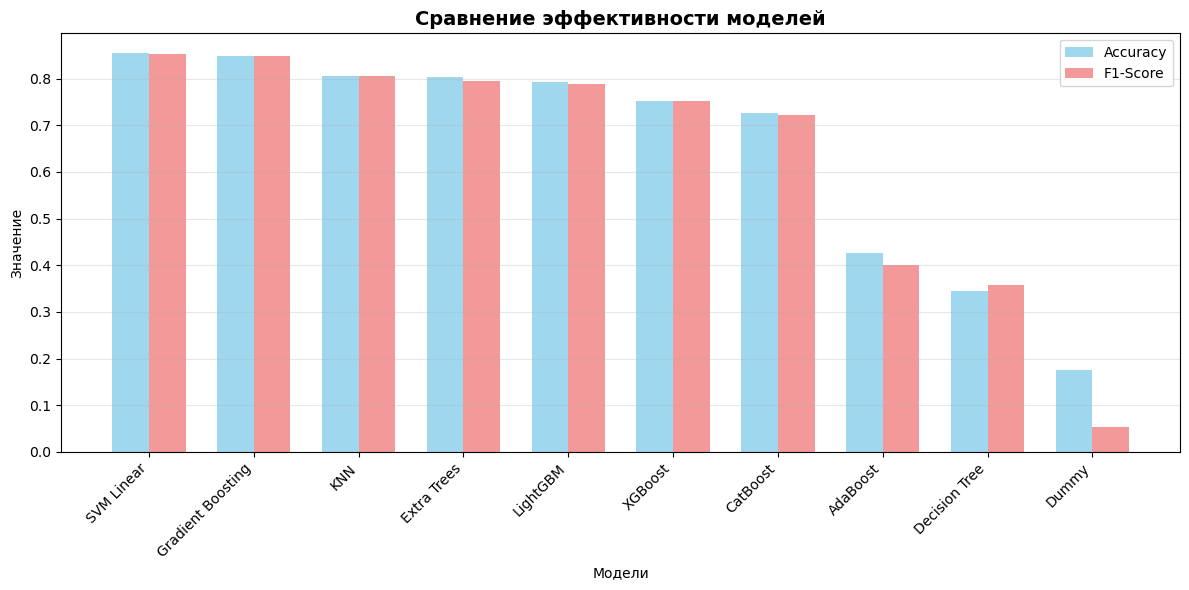

In [129]:
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Accuracy'], width, label='Accuracy', alpha=0.8, color='skyblue')
plt.bar(x_pos + width/2, results_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='lightcoral')

plt.xlabel('Модели')
plt.ylabel('Значение')
plt.title('Сравнение эффективности моделей', fontweight='bold', fontsize=14)
plt.xticks(x_pos, results_df.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [138]:
#Детальнее смотрю на метрики лучшей модели
best_model_name = results_df.index[0]
print(f" Лучшая модель: {best_model_name}")
print(f"   Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")

 Лучшая модель: SVM Linear
   Accuracy: 0.8544
   F1-Score: 0.8521
